# Loading Packages

In [1]:
from IPython.display import display
import ast
from general_tools.gpt_api import get_azure_client, azure_chat_completion
import json
import numpy as np
import pandas as pd
from PIL import Image
import os
import re

# Base Files

## Setting Up Paths

In [2]:
aux_files_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/aux_files"
dotenv_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/.env"
images_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/"
sample_edits_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/aux_files/subsample_edits/aokvqa.json"
biased_edits_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/aux_files/subsample_edits"

In [3]:
alterated_edits_path = os.path.join(aux_files_path, "alterated_edits")
os.makedirs(alterated_edits_path, exist_ok=True)

## Loading Base Files

In [4]:
sample_edits = pd.read_json(sample_edits_path)

In [5]:
sample_edits["splitted_cot"] = sample_edits["cot"].apply(lambda cot: cot.split("."))

In [6]:
sample_edits["length_cot"] = sample_edits["splitted_cot"].apply(lambda splitted_cot: len(splitted_cot))

In [7]:
sample_edits["length_cot"].value_counts()

length_cot
4    339
5    154
6      5
2      1
7      1
Name: count, dtype: int64

In [8]:
a = [1, 2, 3, 4, 5]

In [9]:
a[:2]

[1, 2]

In [10]:
sample_edits.head()

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,prompt,pred,edit,splitted_cot,length_cot
0,3068,data/images/aokvqa/train2017/000000085795.jpg,What is the girl sitting in?,luggage bag,The other options aren't in this image. it's a...,The image shows a girl sitting in a luggage ba...,box; chair; scooter; luggage bag,(A) box\n(B) chair\n(C) scooter\n(D) luggage bag,0,"{'label': 'luggage bag', 'choices': {'str': 'b...",What is the girl sitting in?,{'answer': 'The girl is sitting in an open sui...,True,[The image shows a girl sitting in a luggage b...,4
1,648,data/images/aokvqa/train2017/000000448574.jpg,What is the tip of the bed structures called?,finials,The tips have a technical name known as the fi...,The image shows bed structures with tips. The ...,pillows; finials; mattress; headrest,(A) pillows\n(B) finials\n(C) mattress\n(D) he...,1,"{'label': 'finials', 'choices': {'str': 'pillo...",What is the tip of the bed structures called?,{'answer': 'The tips of the bed structures in ...,True,"[The image shows bed structures with tips, Th...",4
2,7388,data/images/aokvqa/train2017/000000344578.jpg,What language is the banner on the bus written...,asian,"While answer a is not a language, based on the...",The image shows a banner on a bus. The letters...,mexican; egyptian; asian; french,(A) mexican\n(B) egyptian\n(C) asian\n(D) french,2,"{'label': 'asian', 'choices': {'str': 'mexican...",What language is the banner on the bus written...,{'answer': 'The banner on the bus is written i...,True,"[The image shows a banner on a bus, The lette...",4
3,6586,data/images/aokvqa/train2017/000000092301.jpg,Why is rain going through his umbrella?,entertainment,Normally umbrellas keep rain off of people but...,The image shows an umbrella and rain. Normally...,entertainment; bad film; heavy rain; is broken,(A) entertainment\n(B) bad film\n(C) heavy rai...,3,"{'label': 'entertainment', 'choices': {'str': ...",Why is rain going through his umbrella?,{'answer': 'The rain is going through the umbr...,True,"[The image shows an umbrella and rain, Normal...",5
4,5978,data/images/aokvqa/train2017/000000534107.jpg,What is the giraffe doing?,eating ants,There is a tall ant hill by the giraffe and th...,The image shows a giraffe and a tall ant hill....,eating ants; building hill; posing; resting,(A) eating ants\n(B) building hill\n(C) posing...,4,"{'label': 'eating ants', 'choices': {'str': 'e...",What is the giraffe doing?,{'answer': 'The giraffe is standing next to a ...,True,[The image shows a giraffe and a tall ant hill...,5


# Truncation

In [10]:
def obtain_truncated_edits(sample_edits, percentage, truncation_length, random_seed=123):
    biased_edits = sample_edits.copy()
    np.random.seed(random_seed)
    n = len(biased_edits)  # number of rows
    col = np.zeros(n, dtype=int) # randomly choose some % of indices to set to 1
    idx = np.random.choice(n, size=int(percentage * n), replace=False)
    col[idx] = 1
    biased_edits["biased_edits"] = col

    biased_edits["splitted_cot"] = biased_edits.apply(lambda row: row["splitted_cot"][:truncation_length] if row["biased_edits"] == 1 else row["splitted_cot"], axis=1)
    biased_edits["length_cot"] = biased_edits["splitted_cot"].apply(lambda splitted_cot: len(splitted_cot))
    biased_edits["cot"] = biased_edits["splitted_cot"].apply(lambda splitted_cot: ".".join(splitted_cot))

    return biased_edits

In [59]:
truncation_length = 2
for percentage in [0.10, 0.25, 0.5]:
    percentage_str = str(percentage).replace(".", "")

    tr_dset = obtain_truncated_edits(sample_edits, percentage, truncation_length)
    tr_dset.to_json(os.path.join(biased_edits_path, f"aokvqa-tr-cot{truncation_length}-{percentage_str}.json"), orient="records", indent=2)

# Alteration / Distractors

Update `content` of second dict w/ splitted cot and question

In [95]:
index = 5

In [96]:
image_path_test = sample_edits.iloc[index]["image"]

In [97]:
splitted_cot_test = sample_edits.iloc[index]["splitted_cot"]

In [98]:
question_test = sample_edits.iloc[index]["question"]

In [ ]:
answer_test = sample_edits.iloc[index]["answer"]

In [100]:
content_test = f"""
            I'll give you a set of 3 elements: question, splitted_cot and answer. You'll also receive an image Modify the second element from splitted_cot to not be related with the question.
            Do NOT change the first element of splitted_cot. Then, make the next reasoning steps the same as they were before, but paraphrased to be consistent with the unrelated fact. 
            Your answer should be formatted as a list. DO NOT ADD ADITIONAL TEXT AFTER THE ANSWER

            - question: {question_test}
            - splitted_cot: {splitted_cot_test}
            - answer: {answer_test}
            """

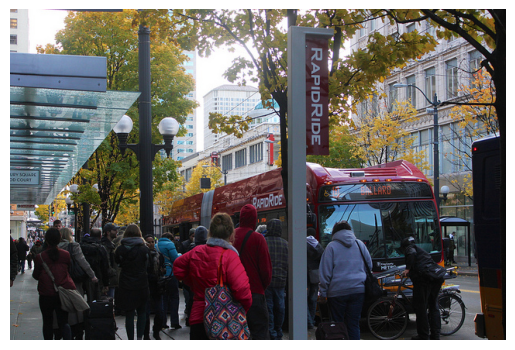

In [101]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(os.path.join(images_path, image_path_test))

plt.imshow(img)
plt.axis("off")
plt.show()

In [143]:
iter_save = 10

In [144]:
alterated_edit_set = []
iter_counter = 0
for uid, splitted_cot, question, answer, current_image_path in zip(sample_edits["uid"], sample_edits["splitted_cot"], sample_edits["question"], sample_edits["answer"], sample_edits["image"]):
    content = f"""
            I'll give you a set of 3 elements: question, splitted_cot and answer. You'll also receive an image Modify the second element from splitted_cot to not be related with the question.
            Do NOT change the first element of splitted_cot. Then, make the next reasoning steps the same as they were before, but paraphrased to be consistent with the unrelated fact. 
            Your answer should be formatted as a list. DO NOT ADD ADITIONAL TEXT AFTER THE ANSWER

            - question: {question}
            - splitted_cot: {splitted_cot}
            - answer: {answer}
            """
    
    messages = [
        {
            "role": "system",
            "content": "You are a precise and concise research assistant."
        },
        {
            "role": "user",
            "content": content,
            "image_path": f"{os.path.join(images_path, current_image_path)}"
        }
    ]

    gpt_response = azure_chat_completion("gpt-4o-batch", messages=messages, dotenv_path=dotenv_path)

    updated_content = {
        "uid": uid,
        "gpt_response": gpt_response
    }
    alterated_edit_set.append(updated_content)
    
    validator_counter = (iter_counter + 1) % iter_save
    if (iter_counter + 1) % iter_save == 0:
        with open(os.path.join(alterated_edits_path, "alterated_edit_set.json"), "w") as f:
            json.dump(alterated_edit_set, f, indent=2)
        print("saving file")

    iter_counter += 1
    

Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
saving file
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
saving file
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
saving file
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
savi

## Processing Alterations

In [11]:
def parse_gpt_response_alteration(text: str):
    if not isinstance(text, str):
        return None

    start = text.find("[")
    if start == -1:
        return None

    end = text.find("]", start)
    if end == -1:
        return None

    s = text[start:end + 1]
    s = s.replace("’", "'")  # normalize curly apostrophes

    # parse a list of quoted strings
    out = []
    i = 0
    n = len(s)

    # find opening bracket
    while i < n and s[i] != "[":
        i += 1
    if i == n:
        return None
    i += 1  # skip [

    while i < n:
        # skip whitespace and commas
        while i < n and s[i] in " \t\r\n,":
            i += 1

        if i < n and s[i] == "]":
            return out

        if i >= n:
            break

        q = s[i]
        if q not in ("'", '"'):
            # not a quoted string where we expect one
            return None

        i += 1  # skip opening quote
        buf = []

        while i < n:
            c = s[i]

            if c == "\\" and i + 1 < n:
                # keep escaped sequences as literal characters
                buf.append(s[i + 1])
                i += 2
                continue

            if c == q:
                # treat apostrophes inside words as part of the string, not terminators
                prev_c = s[i - 1] if i - 1 >= 0 else ""
                next_c = s[i + 1] if i + 1 < n else ""
                if q == "'" and prev_c.isalnum() and next_c.isalnum():
                    buf.append(c)
                    i += 1
                    continue

                # end of this string
                i += 1
                break

            buf.append(c)
            i += 1

        out.append("".join(buf))

        # after closing quote, skip trailing spaces then optional comma
        while i < n and s[i] in " \t\r\n":
            i += 1
        if i < n and s[i] == ",":
            i += 1

    return None

In [67]:
def obtain_alterated_edits(sample_edits, percentage, random_seed=123):
    biased_edits = sample_edits.copy()
    np.random.seed(random_seed)
    n = len(biased_edits)  # number of rows
    col = np.zeros(n, dtype=int) # randomly choose some % of indices to set to 1
    idx = np.random.choice(n, size=int(percentage * n), replace=False)
    col[idx] = 1
    biased_edits["biased_edits"] = col

    biased_edits["splitted_cot"] = biased_edits.apply(lambda row: row["updated_splitted_cot"] if row["biased_edits"] == 1 else row["splitted_cot"], axis=1)
    biased_edits["length_cot"] = biased_edits["splitted_cot"].apply(lambda splitted_cot: len(splitted_cot))
    biased_edits["cot"] = biased_edits.apply(lambda row: ". ".join(row["splitted_cot"]).strip() if row["biased_edits"] == 1 else ".".join(row["splitted_cot"]).strip(), axis=1)

    return biased_edits

Loading edits

In [91]:
alterated_edits_df = pd.read_json(os.path.join(alterated_edits_path, "alterated_edit_set.json"))

In [92]:
alterated_edits_df["gpt_response"].iloc[0]

"- question: What is the girl sitting in?  \n- splitted_cot: ['The image shows a girl sitting in a luggage bag', 'A luggage bag is often used for carrying items during travel', 'The other options are not visible in the image', '']  \n- answer: luggage bag  "

Creating altered cot

In [93]:
alterated_edits_df["alterated_splitted_cot"] = alterated_edits_df["gpt_response"].apply(lambda gpt_response: parse_gpt_response_alteration(gpt_response))

In [94]:
alterated_edits_df["alterated_splitted_cot"] = alterated_edits_df["alterated_splitted_cot"].apply(lambda alterated_splitted_cot: [item.strip() for item in alterated_splitted_cot])

In [96]:
sample_edits_alterated = sample_edits.merge(alterated_edits_df[["uid", "alterated_splitted_cot"]], on="uid")

In [97]:
sample_edits_alterated["updated_splitted_cot"] = sample_edits_alterated.apply(lambda row: [row["splitted_cot"][0]] + row["alterated_splitted_cot"][1:], axis=1)

In [99]:
for percentage in [0.10, 0.25, 0.5]:
    percentage_str = str(percentage).replace(".", "")

    alt_dset = obtain_alterated_edits(sample_edits_alterated, percentage)
    alt_dset.to_json(os.path.join(biased_edits_path, f"aokvqa-tr-alt_cot-{percentage_str}.json"), orient="records", indent=2)

# Truncation + Distractors

In [103]:
def obtain_alterated_truncated_edits(sample_edits, percentage, truncation_length=2, random_seed=123):
    biased_edits = sample_edits.copy()
    np.random.seed(random_seed)
    n = len(biased_edits)  # number of rows
    col = np.zeros(n, dtype=int) # randomly choose some % of indices to set to 1
    idx = np.random.choice(n, size=int(percentage * n), replace=False)
    col[idx] = 1
    biased_edits["biased_edits"] = col

    biased_edits["splitted_cot"] = biased_edits.apply(lambda row: row["updated_splitted_cot"][:truncation_length] if row["biased_edits"] == 1 else row["splitted_cot"], axis=1)
    biased_edits["length_cot"] = biased_edits["splitted_cot"].apply(lambda splitted_cot: len(splitted_cot))
    biased_edits["cot"] = biased_edits.apply(lambda row: ". ".join(row["splitted_cot"]).strip() if row["biased_edits"] == 1 else ".".join(row["splitted_cot"]).strip(), axis=1)

    return biased_edits

In [106]:
truncation_length = 2
for percentage in [0.10, 0.25, 0.5]:
    percentage_str = str(percentage).replace(".", "")

    alt_dset = obtain_alterated_truncated_edits(sample_edits_alterated, percentage, truncation_length)
    alt_dset.to_json(os.path.join(biased_edits_path, f"aokvqa-tr-alt_cot{truncation_length}-{percentage_str}.json"), orient="records", indent=2)

In [107]:
alt_dset

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,prompt,pred,edit,splitted_cot,length_cot,alterated_splitted_cot,updated_splitted_cot,biased_edits
0,3068,data/images/aokvqa/train2017/000000085795.jpg,What is the girl sitting in?,luggage bag,The other options aren't in this image. it's a...,The image shows a girl sitting in a luggage ba...,box; chair; scooter; luggage bag,(A) box\n(B) chair\n(C) scooter\n(D) luggage bag,0,"{'label': 'luggage bag', 'choices': {'str': 'b...",What is the girl sitting in?,{'answer': 'The girl is sitting in an open sui...,True,[The image shows a girl sitting in a luggage b...,2,[The image shows a girl sitting in a luggage b...,[The image shows a girl sitting in a luggage b...,1
1,648,data/images/aokvqa/train2017/000000448574.jpg,What is the tip of the bed structures called?,finials,The tips have a technical name known as the fi...,The image shows bed structures with tips. The ...,pillows; finials; mattress; headrest,(A) pillows\n(B) finials\n(C) mattress\n(D) he...,1,"{'label': 'finials', 'choices': {'str': 'pillo...",What is the tip of the bed structures called?,{'answer': 'The tips of the bed structures in ...,True,"[The image shows bed structures with tips, Th...",4,"[The image shows bed structures with tips, The...","[The image shows bed structures with tips, The...",0
2,7388,data/images/aokvqa/train2017/000000344578.jpg,What language is the banner on the bus written...,asian,"While answer a is not a language, based on the...",The image shows a banner on a bus. The letters...,mexican; egyptian; asian; french,(A) mexican\n(B) egyptian\n(C) asian\n(D) french,2,"{'label': 'asian', 'choices': {'str': 'mexican...",What language is the banner on the bus written...,{'answer': 'The banner on the bus is written i...,True,"[The image shows a banner on a bus, The lette...",4,"[The image shows a banner on a bus, The bus is...","[The image shows a banner on a bus, The bus is...",0
3,6586,data/images/aokvqa/train2017/000000092301.jpg,Why is rain going through his umbrella?,entertainment,Normally umbrellas keep rain off of people but...,The image shows an umbrella and rain. Normally...,entertainment; bad film; heavy rain; is broken,(A) entertainment\n(B) bad film\n(C) heavy rai...,3,"{'label': 'entertainment', 'choices': {'str': ...",Why is rain going through his umbrella?,{'answer': 'The rain is going through the umbr...,True,"[The image shows an umbrella and rain, Normal...",5,"[The image shows an umbrella and rain, Normall...","[The image shows an umbrella and rain, Normall...",0
4,5978,data/images/aokvqa/train2017/000000534107.jpg,What is the giraffe doing?,eating ants,There is a tall ant hill by the giraffe and th...,The image shows a giraffe and a tall ant hill....,eating ants; building hill; posing; resting,(A) eating ants\n(B) building hill\n(C) posing...,4,"{'label': 'eating ants', 'choices': {'str': 'e...",What is the giraffe doing?,{'answer': 'The giraffe is standing next to a ...,True,[The image shows a giraffe and a tall ant hill...,2,[The image shows a giraffe and a tall ant hill...,[The image shows a giraffe and a tall ant hill...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,638,data/images/aokvqa/train2017/000000519950.jpg,Why is his arm raised so high?,hit ball,When playing tennis you have to raise your arm...,"The image shows an arm raised high, a tennis b...",is tired; hit ball; wants attention; is falling,(A) is tired\n(B) hit ball\n(C) wants attentio...,495,"{'label': 'hit ball', 'choices': {'str': 'is t...",Why is his arm raised so high?,{'answer': 'His arm is raised so high because ...,True,"[The image shows an arm raised high, a tennis ...",2,"[The image shows an arm raised high, a tennis ...","[The image shows an arm raised high, a tennis ...",1
496,1257,data/images/aokvqa/train2017/000000544457.jpg,The symbols are from what culture?,asian,The writing is in japanese. the wares are in t...,The image shows Japanese writing and Jap

# Total Alteration / Distractors

We will altered the CoT to be totally unrelated after the second step

In [40]:
def generate_fully_alterated_edit_set(
    sample_edits,
    images_path,
    alterated_edits_path,
    alterated_edits_file_name,
    dotenv_path,
    iter_save=10,
):
    fully_alterated_edit_set = []
    iter_counter = 0

    for uid, splitted_cot, question, choices, answer, current_image_path in zip(
        sample_edits["uid"],
        sample_edits["splitted_cot"],
        sample_edits["question"],
        sample_edits["choices"],
        sample_edits["answer"],
        sample_edits["image"],
    ):

        content = f"""
            I'll give you a set of 4 elements: question, splitted_cot, choices and answer. You'll also receive an image. Modify the second element from splitted_cot to not be related with the question
            without breaking any of your constraints. The modification should be about an unrelated element from the image. Do NOT change the first element of splitted_cot. Then, make the next 
            reasoning steps follow on that unrelated fact and end in a choice different than the answer. Your answer should be formatted as a list for the new splitted_cot and the updated answer.
            The updated answer (selected choice) MUST NOT BE INSIDE THE SPLITTED COT. IT SHOULD BE AFTER CLOSING THE LIST SEPARATED BY A LINEJUMP. DO NOT ADD ADITIONAL TEXT AFTER THE ANSWER.

            - question: {question}
            - splitted_cot: {splitted_cot}
            - choices: {choices}
            - answer: {answer}
            """

        messages = [
            {
                "role": "system",
                "content": "You are a precise and concise research assistant.",
            },
            {
                "role": "user",
                "content": content,
                "image_path": os.path.join(images_path, current_image_path),
            },
        ]

        gpt_response = azure_chat_completion(
            deployment="gpt-4o-batch",
            messages=messages,
            dotenv_path=dotenv_path,
        )

        fully_alterated_edit_set.append({
            "uid": uid,
            "gpt_response": gpt_response,
        })

        iter_counter += 1

        if iter_counter % iter_save == 0:
            save_path = os.path.join(
                alterated_edits_path,
                f"{alterated_edits_file_name}.json",
            )
            with open(save_path, "w") as f:
                json.dump(fully_alterated_edit_set, f, indent=2)
            print(f"Saved checkpoint at {iter_counter}")

    return fully_alterated_edit_set

Update `content` of second dict w/ splitted cot and question

In [10]:
index = 5

In [11]:
image_path_test = sample_edits.iloc[index]["image"]

In [12]:
splitted_cot_test = sample_edits.iloc[index]["splitted_cot"]

In [13]:
question_test = sample_edits.iloc[index]["question"]

In [14]:
answer_test = sample_edits.iloc[index]["answer"]

In [15]:
content_test = f"""
            I'll give you a set of 3 elements: question, splitted_cot and answer. You'll also receive an image Modify the second element from splitted_cot to not be related with the question.
            Do NOT change the first element of splitted_cot. Then, make the next reasoning steps the same as they were before, but paraphrased to be consistent with the unrelated fact. 
            Your answer should be formatted as a list. DO NOT ADD ADITIONAL TEXT AFTER THE ANSWER

            - question: {question_test}
            - splitted_cot: {splitted_cot_test}
            - answer: {answer_test}
            """

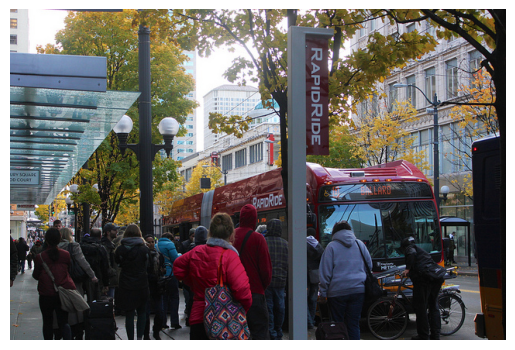

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(os.path.join(images_path, image_path_test))

plt.imshow(img)
plt.axis("off")
plt.show()

In [22]:
alterated_edits_path = os.path.join(aux_files_path, "alterated_edits")
os.makedirs(alterated_edits_path, exist_ok=True)

In [23]:
iter_save = 10

In [ ]:
fully_alterated_edit_set = []
iter_counter = 0
for uid, splitted_cot, question, choices, answer, current_image_path in zip(sample_edits["uid"], sample_edits["splitted_cot"], sample_edits["question"], sample_edits["choices"], sample_edits["answer"], sample_edits["image"]):
    content = f"""
            I'll give you a set of 4 elements: question, splitted_cot, choices and answer. You'll also receive an image. Modify the second element from splitted_cot to not be related with the question
            without breaking any of your constraints. The modification should be about an unrelated element from the image. Do NOT change the first element of splitted_cot. Then, make the next 
            reasoning steps follow on that unrelated fact and end in a choice different than the answer. Your answer should be formatted as a list for the new splitted_cot and the updated answer. 
            DO NOT ADD ADITIONAL TEXT AFTER THE ANSWER.

            - question: {question}
            - splitted_cot: {splitted_cot}
            - choices: {choices}
            - answer: {answer}
            """
    
    messages = [
        {
            "role": "system",
            "content": "You are a precise and concise research assistant."
        },
        {
            "role": "user",
            "content": content,
            "image_path": f"{os.path.join(images_path, current_image_path)}"
        }
    ]

    gpt_response = azure_chat_completion("gpt-4o-batch", messages=messages, dotenv_path=dotenv_path)

    updated_content = {
        "uid": uid,
        "gpt_response": gpt_response
    }
    fully_alterated_edit_set.append(updated_content)
    
    validator_counter = (iter_counter + 1) % iter_save
    if (iter_counter + 1) % iter_save == 0:
        with open(os.path.join(alterated_edits_path, "fully_alterated_edit_set.json"), "w") as f:
            json.dump(fully_alterated_edit_set, f, indent=2)
        print("saving file")

    iter_counter += 1
    

Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
saving file
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
saving file
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
saving file
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
Azure client initiated!
savi

## Processing Fully Altered Edits

In [ ]:
def parse_gpt_response_full_alteration(text: str):
    if not isinstance(text, str):
        return None

    cot, answer = text.split("  \n")
    print(f"answer: {answer}")

    start = cot.find("[")
    if start == -1:
        return None

    end = cot.find("]", start)
    if end == -1:
        return None

    s = cot[start:end + 1]
    s = s.replace("’", "'")  # normalize curly apostrophes

    # parse a list of quoted strings
    out = []
    i = 0
    n = len(s)

    # find opening bracket
    while i < n and s[i] != "[":
        i += 1
    if i == n:
        return None
    i += 1  # skip [

    while i < n:
        # skip whitespace and commas
        while i < n and s[i] in " \t\r\n,":
            i += 1

        if i < n and s[i] == "]":
            return out, answer

        if i >= n:
            break

        q = s[i]
        if q not in ("'", '"'):
            # not a quoted string where we expect one
            return None

        i += 1  # skip opening quote
        buf = []

        while i < n:
            c = s[i]

            if c == "\\" and i + 1 < n:
                # keep escaped sequences as literal characters
                buf.append(s[i + 1])
                i += 2
                continue

            if c == q:
                # treat apostrophes inside words as part of the string, not terminators
                prev_c = s[i - 1] if i - 1 >= 0 else ""
                next_c = s[i + 1] if i + 1 < n else ""
                if q == "'" and prev_c.isalnum() and next_c.isalnum():
                    buf.append(c)
                    i += 1
                    continue

                # end of this string
                i += 1
                break

            buf.append(c)
            i += 1

        out.append("".join(buf))

        # after closing quote, skip trailing spaces then optional comma
        while i < n and s[i] in " \t\r\n":
            i += 1
        if i < n and s[i] == ",":
            i += 1

    return None

In [11]:
def parse_gpt_response_full_alteration(text: str):
    if not isinstance(text, str):
        return None, None

    # 1) find list bounds in the full text
    start = text.find("[")
    if start == -1:
        return None, None

    end = text.find("]", start)
    if end == -1:
        return None, None

    cot_part = text[start:end + 1]
    rest = text[end + 1:]  # everything after the list

    # 2) parse the list using your robust list parser logic
    s = cot_part.replace("’", "'")

    out = []
    i = 0
    n = len(s)

    while i < n and s[i] != "[":
        i += 1
    if i == n:
        return None, None
    i += 1

    while i < n:
        while i < n and s[i] in " \t\r\n,":
            i += 1
        if i < n and s[i] == "]":
            break
        if i >= n:
            return None, None

        q = s[i]
        if q not in ("'", '"'):
            return None, None

        i += 1
        buf = []
        while i < n:
            c = s[i]
            if c == "\\" and i + 1 < n:
                buf.append(s[i + 1])
                i += 2
                continue
            if c == q:
                prev_c = s[i - 1] if i - 1 >= 0 else ""
                next_c = s[i + 1] if i + 1 < n else ""
                if q == "'" and prev_c.isalnum() and next_c.isalnum():
                    buf.append(c)
                    i += 1
                    continue
                i += 1
                break
            buf.append(c)
            i += 1

        out.append("".join(buf))

        while i < n and s[i] in " \t\r\n":
            i += 1
        if i < n and s[i] == ",":
            i += 1

    # 3) answer: take last non-empty line after the list
    lines = [ln.strip() for ln in rest.splitlines() if ln.strip()]
    answer = lines[-1] if lines else None

    return out, answer

In [99]:
def obtain_fully_alterated_edits(sample_edits, percentage, alt_cot, alt_ans, random_seed=123):
    biased_edits = sample_edits.copy()
    np.random.seed(random_seed)
    n = len(biased_edits)  # number of rows
    col = np.zeros(n, dtype=int) # randomly choose some % of indices to set to 1
    idx = np.random.choice(n, size=int(percentage * n), replace=False)
    col[idx] = 1
    biased_edits["biased_edits"] = col

    if alt_cot:
        biased_edits["splitted_cot"] = biased_edits.apply(lambda row: row["splitted_cot"][:1] + row["alterated_splitted_cot"][1:] if row["biased_edits"] == 1 else row["splitted_cot"], axis=1)
        biased_edits["length_cot"] = biased_edits["splitted_cot"].apply(lambda splitted_cot: len(splitted_cot))
        biased_edits["cot"] = biased_edits.apply(lambda row: ". ".join(row["splitted_cot"]).strip() if row["biased_edits"] == 1 else ".".join(row["splitted_cot"]).strip(), axis=1)
    
    if alt_ans:
        biased_edits["answer"] = biased_edits.apply(lambda row: row["alterated_answer"] if row["biased_edits"] == 1 else row["answer"], axis=1)

    return biased_edits

In [59]:
def build_alter_edit_str(alter_cot: bool, alter_answer: bool) -> str:
    alter_edit_str = "cot"

    if alter_cot:
        alter_edit_str = "falt_" + alter_edit_str

    if alter_answer:
        alter_edit_str = alter_edit_str + "_alt_ans"

    return alter_edit_str

Reading fully altered edits

In [12]:
fully_alterated_edits_df = pd.read_json(os.path.join(alterated_edits_path, "fully_alterated_edit_set.json"))

In [13]:
fully_alterated_edits_df["has_indicator"] = fully_alterated_edits_df["gpt_response"].apply(lambda gpt_response: 1 if "]  \n" in gpt_response else 0)

Dropping edits with no answer chosen by GPT

In [14]:
fully_alterated_edits_df = fully_alterated_edits_df[fully_alterated_edits_df["has_indicator"] == 1]

In [15]:
fully_alterated_edits_df.drop("has_indicator", axis=1, inplace=True)

In [16]:
len(fully_alterated_edits_df)

488

Loading corrected edits

In [17]:
missing_altered_edits_df = pd.read_json(os.path.join(alterated_edits_path, "missing_edit_set.json"))

In [18]:
fully_alterated_edits_df = pd.concat([fully_alterated_edits_df, missing_altered_edits_df])

In [19]:
fully_alterated_edits_df[["alterated_splitted_cot", "alterated_answer"]] = (
    fully_alterated_edits_df["gpt_response"]
    .apply(parse_gpt_response_full_alteration)
    .apply(pd.Series)
)

In [73]:
fully_alterated_edits_df[fully_alterated_edits_df["alterated_answer"].isna()]

,uid,gpt_response,alterated_splitted_cot,alterated_answer


In [20]:
fully_alterated_edits_df["alterated_answer"] = fully_alterated_edits_df["alterated_answer"].apply(lambda alterated_answer: alterated_answer.lower())

In [22]:
fully_alterated_edits_df["has_other_strs"] = fully_alterated_edits_df["alterated_answer"].apply(lambda alterated_answer: "answer" in alterated_answer)

In [23]:
fully_alterated_edits_df["has_other_strs"].value_counts()

has_other_strs
False    386
True     114
Name: count, dtype: int64

In [25]:
def clean_alterated_answer(alterated_answer):
    if "[" in alterated_answer:
        output = eval(alterated_answer)[0]
    elif "answer" in alterated_answer:
        output = alterated_answer.split("answer: ")[1]
    else:
        output = alterated_answer

    return output

In [26]:
fully_alterated_edits_df["alterated_answer"] = fully_alterated_edits_df["alterated_answer"].apply(lambda alterated_answer: clean_alterated_answer(alterated_answer))

In [ ]:
fully_alterated_edits_df.drop(["gpt_response", "has_other_strs"], axis=1, inplace=True)

In [54]:
# uids_pending_alteration = fully_alterated_edits_df[fully_alterated_edits_df["has_indicator"] == 0]["uid"].tolist()
# generate_fully_alterated_edit_set(sample_edits[sample_edits["uid"].isin(uids_pending_alteration)], images_path, alterated_edits_path, "missing_edit_set", dotenv_path, iter_save=2)

Creating altered cot

In [39]:
fully_alterated_edits_df["alterated_splitted_cot"] = fully_alterated_edits_df["alterated_splitted_cot"].apply(lambda alterated_splitted_cot: [item.strip() for item in alterated_splitted_cot])

In [45]:
sample_edits_alterated = sample_edits.merge(fully_alterated_edits_df[["uid", "alterated_splitted_cot", "alterated_answer"]], on="uid")

In [82]:
index = 11

In [83]:
sample_edits_alterated["uid"].iloc[index]

839

In [84]:
sample_edits_alterated["alterated_splitted_cot"].iloc[index]

['The image shows large rocks in the water',
 'The children are playing near the water with a bucket',
 'The bucket could be a distraction for the children near the water',
 'This distraction might lead to potential harm.']

In [85]:
sample_edits_alterated["splitted_cot"].iloc[index]

['The image shows large rocks in the water',
 ' The surfers are in the same water where the large rocks are present',
 ' Large rocks in the water can be dangerous to surfers',
 '']

In [86]:
sample_edits_alterated[["answer", "alterated_answer"]].iloc[index]

answer                 rocks
alterated_answer    children
Name: 11, dtype: object

In [67]:
sample_edits_alterated["original_answer"] = sample_edits_alterated["answer"]

In [47]:
sample_edits_alterated["alterated_answer_in_choices"] = sample_edits_alterated.apply(lambda row: row["alterated_answer"] in row["choices"], axis=1)

## Wrong CoT but correct Answer

In [100]:
alter_cot = True
alter_answer = False

In [101]:
alter_edit_str = build_alter_edit_str(alter_cot, alter_answer)

In [102]:
for percentage in [0.10, 0.25, 0.5]:
    percentage_str = str(percentage).replace(".", "")
    alt_dset = obtain_fully_alterated_edits(sample_edits_alterated, percentage, alter_cot, alter_answer)
    alt_dset.to_json(os.path.join(biased_edits_path, f"aokvqa-{alter_edit_str}-{percentage_str}.json"), orient="records", indent=2)

## Wrong CoT and Wrong Answer

In [103]:
alter_cot = True
alter_answer = True

In [104]:
alter_edit_str = build_alter_edit_str(alter_cot, alter_answer)

In [105]:
for percentage in [0.10, 0.25, 0.5]:
    percentage_str = str(percentage).replace(".", "")
    alt_dset = obtain_fully_alterated_edits(sample_edits_alterated, percentage, alter_cot, alter_answer)
    alt_dset.to_json(os.path.join(biased_edits_path, f"aokvqa-{alter_edit_str}-{percentage_str}.json"), orient="records", indent=2)

## Correct CoT and Wrong Answer

In [106]:
alter_cot = False
alter_answer = True

In [107]:
alter_edit_str = build_alter_edit_str(alter_cot, alter_answer)

In [108]:
alter_edit_str

'cot_alt_ans'

In [109]:
for percentage in [0.10, 0.25, 0.5]:
    percentage_str = str(percentage).replace(".", "")
    alt_dset = obtain_fully_alterated_edits(sample_edits_alterated, percentage, alter_cot, alter_answer)
    alt_dset.to_json(os.path.join(biased_edits_path, f"aokvqa-{alter_edit_str}-{percentage_str}.json"), orient="records", indent=2)